In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_preproc import df_mini_preproc

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

null_mask = df.isnull()
missing = null_mask.sum().sort_values(ascending=False)
missing_cells = null_mask.sum().sum()
missing_pct = null_mask.mean().mul(100).sort_values(ascending=False)
num_cols = df.select_dtypes(include=np.number).columns
total_cells = df.size
completeness = df.notna().to_numpy().mean()
dup_rate = df.duplicated().sum() / len(df)

readiness_score = (
    completeness * 70 +
    (1 - dup_rate) * 30
)



C:\Users\SamsungNot\OneDrive\Área de Trabalho\FIAP\FIAP_challenge_1\src\data_preproc.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].str.strip().replace(binary_map)


In [3]:
print("\n\nVOLUME DO DATASET")
print("Linhas e colunas:", df.shape)
print("\nColunas:")
print(df.columns)
print("\nTipos de dados:")
print(df.dtypes)



VOLUME DO DATASET
Linhas e colunas: (7043, 20)

Colunas:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Tipos de dados:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int

In [4]:
print("\n\nQUALIDADE DOS DADOS")
print("\nValores ausentes por coluna:")
print(missing)
print("\n% valores ausentes:")
print(missing_pct)
print("\nLinhas duplicadas:", df.duplicated().sum())
print("\nResumo estatístico:")

df = df_mini_preproc(df)
print(df.describe(include="all"))



QUALIDADE DOS DADOS

Valores ausentes por coluna:
TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

% valores ausentes:
TotalCharges        0.156183
gender              0.000000
Partner             0.000000
SeniorCitizen       0.000000
Dependents          0.000000
tenure              0.000000
MultipleLines       0.000000
PhoneService        0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
InternetService     0.000000
TechSupport         0.000000
StreamingTV         0.000000
Contract            0.000000
StreamingMovies    

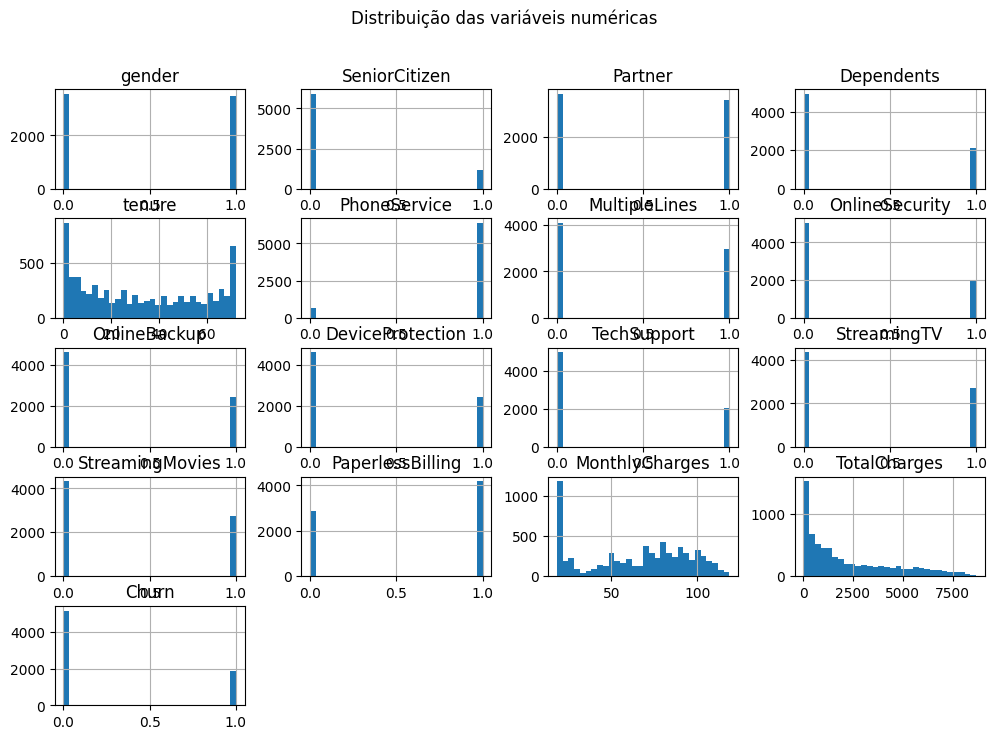

In [5]:
df[num_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribuição das variáveis numéricas")
plt.show()

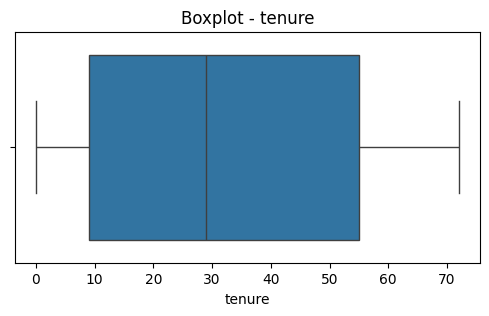

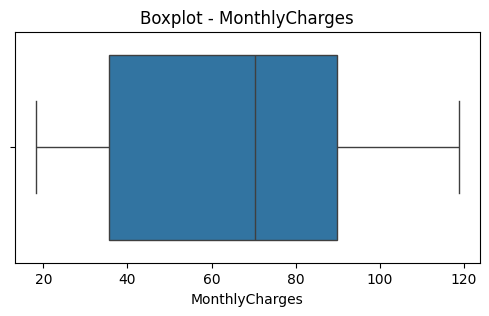

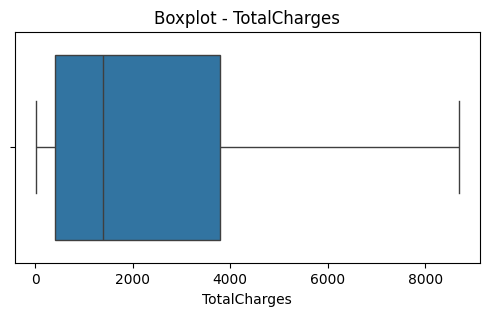

In [6]:
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

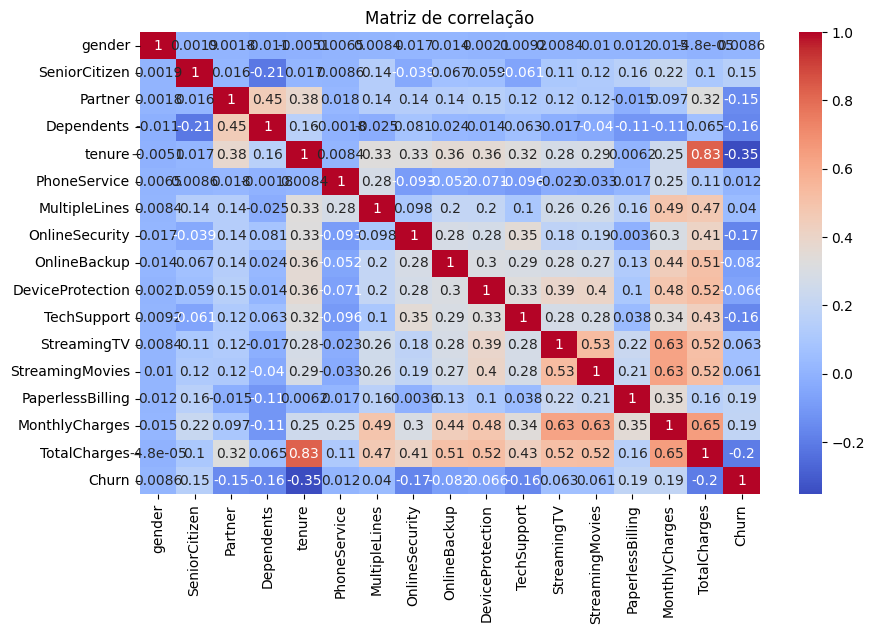

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlação")
plt.show()

In [8]:
print("\n\n DATA READINESS")

print(f"\nCompletude dos dados: {completeness:.2%}")
print(f"\nTaxa de duplicados: {dup_rate:.2%}")

print(f"\nData Readiness Score: {readiness_score:.2f} / 100\n\n")

if readiness_score > 80:
    print("Dataset pronto para análise/modelagem")
elif readiness_score > 60:
    print("Dataset razoável, precisa de limpeza")
else:
    print("Dataset precisa de tratamento significativo")



 DATA READINESS

Completude dos dados: 99.99%

Taxa de duplicados: 0.31%

Data Readiness Score: 99.90 / 100


Dataset pronto para análise/modelagem
